# Predykcja Odejść Klientów Telco - Metody Analizy Danych Projekt 2

**Autorzy:** Filip Michalak, Jakub Michalski, Marek Najmóła  
**Data:** 23.05.2026

## Abstrakt

Celem niniejszej pracy jest predykcja odejść klientów firmy telekomunikacyjnej (Telco) przy użyciu czterech metod klasyfikacji: regresji logistycznej, drzewa decyzyjnego, lasu losowego oraz XGBoost, a także modelu hybrydowego. Analizę przeprowadzono na zbiorze 7043 klientów opisanych 21 zmiennymi. Wyniki wskazują na wysoką skuteczność regresji logistycznej (AUC = 0,842).

**Słowa kluczowe:** klasyfikacja, churn, regresja logistyczna, las losowy, XGBoost, Telco, model hybrydowy


## 1. Wprowadzenie

Retencja klientów jest kluczowym wyzwaniem w branży telekomunikacyjnej. Koszt pozyskania nowego klienta jest znacznie wyższy niż utrzymanie obecnego, według badań przemysłowych, pozyskanie nowego klienta może być nawet 5-25 razy droższe niż retencja istniejącego. Predykcja odejść (churn) pozwala firmom proaktywnie identyfikować klientów zagrożonych rezygnacją i podejmować działania retencyjne zanim dojdzie do faktycznego odejścia.

Współczesne metody uczenia maszynowego oferują zaawansowane narzędzia do analizy historycznych danych i budowy modeli predykcyjnych. W niniejszej pracy zastosowano cztery różne podejścia klasyfikacyjne, od prostego modelu regresji logistycznej po zaawansowane algorytmy zespołowe (Random Forest, XGBoost), a następnie połączono je w model hybrydowy.

**Cel pracy:** Zbudowanie i porównanie modeli klasyfikacyjnych predykcyjnych odejść klientów Telco przy użyciu czterech metod oraz modelu hybrydowego.

**Metody:**
1. **Regresja logistyczna** - klasyczna metoda klasyfikacji binarnej
2. **Drzewo decyzyjne** - interpretowalny model oparty na regułach if-then
3. **Las losowy (Random Forest)** - zespół drzew decyzyjnych
4. **XGBoost** - zaawansowany gradient boosting
5. **Model hybrydowy (Weighted Average)** - ważona średnia prawdopodobieństw


## 2. Przedmiot badania

### 2.1 Dane

Zbiór danych pochodzi z firmy telekomunikacyjnej Telco i zawiera informacje o 7043 klientach opisanych 21 zmiennymi (w tym 1 zmienna docelowa `Churn`). Dane zostały udostępnione przez IBM jako zbiór przykładowy i są powszechnie wykorzystywane w literaturze do benchmarkowania modeli predykcji churn.

**Podstawowe charakterystyki zbioru:**
- Liczba obserwacji: 7043
- Liczba zmiennych: 21 (w tym 1 identyfikator, 1 target)
- Zmienna docelowa: `Churn` (Yes/No)
- Rozkład klasy: 26,5% churn vs 73,5% retencja


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
import os
import warnings
warnings.filterwarnings('ignore')

# Konfiguracja wizualna
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})
sns.set_style("whitegrid")

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Wczytanie danych
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"=== CHARAKTERYSTYKA ZBIORU ===")
print(f"Liczba wierszy: {df.shape[0]}")
print(f"Liczba kolumn: {df.shape[1]}")
print(f"=== TYPY ZMIENNYCH ===")
print(df.dtypes)
print(f"=== BRAKI DANYCH ===")
print(df.isnull().sum()[df.isnull().sum() > 0])


=== CHARAKTERYSTYKA ZBIORU ===
Liczba wierszy: 7043
Liczba kolumn: 21
=== TYPY ZMIENNYCH ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object
=== BRAKI DANYCH ===
TotalCharges    11
dtype: int64


### 2.2 Zmienne w zbiorze

Poniżej przedstawiono wszystkie zmienne w zbiorze danych wraz z ich typem, opisem i zakresem wartości.


In [ ]:
# Tabela zmiennych
var_desc = [
    ('customerID', 'object', 'ID klienta'),
    ('gender', 'object', 'Płeć (Male/Female)'),
    ('SeniorCitizen', 'int64', 'Senior (0/1)'),
    ('Partner', 'object', 'Partner (Yes/No)'),
    ('Dependents', 'object', 'Na utrzymaniu (Yes/No)'),
    ('tenure', 'int64', 'Staż klienta (miesiące)'),
    ('PhoneService', 'object', 'Usługa telefoniczna'),
    ('MultipleLines', 'object', 'Wiele linii'),
    ('InternetService', 'object', 'Usługa internetowa'),
    ('OnlineSecurity', 'object', 'Bezpieczeństwo online'),
    ('OnlineBackup', 'object', 'Kopie zapasowe online'),
    ('DeviceProtection', 'object', 'Ochrona urządzenia'),
    ('TechSupport', 'object', 'Wsparcie techniczne'),
    ('StreamingTV', 'object', 'Telewizja strumieniowa'),
    ('StreamingMovies', 'object', 'Filmy strumieniowe'),
    ('Contract', 'object', 'Rodzaj umowy'),
    ('PaperlessBilling', 'object', 'Fakturowanie elektroniczne'),
    ('PaymentMethod', 'object', 'Metoda płatności'),
    ('MonthlyCharges', 'float64', 'Miesięczna opłata ($)'),
    ('TotalCharges', 'float64', 'Łączna opłata ($)'),
    ('Churn', 'object', 'Odejście klienta (Yes/No)')
]
var_df = pd.DataFrame(var_desc, columns=['Zmienna', 'Typ', 'Opis'])
display(HTML(var_df.to_html(index=False, classes='table table-striped')))

Zmienna,Typ,Opis
customerID,object,ID klienta
gender,object,Płeć (Male/Female)
SeniorCitizen,int64,Senior (0/1)
Partner,object,Partner (Yes/No)
Dependents,object,Na utrzymaniu (Yes/No)
tenure,int64,Staż klienta (miesiące)
PhoneService,object,Usługa telefoniczna
MultipleLines,object,Wiele linii
InternetService,object,Usługa internetowa
OnlineSecurity,object,Bezpieczeństwo online


### 2.3 Statystyki opisowe

#### 2.3.1 Zmienne numeryczne


In [47]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print("=== STATYSTYKI ZMIENNYCH NUMERYCZNYCH ===")
print(df[numeric_cols].describe().round(2).to_string())

from scipy import stats
# Skosnosc
print("\n=== SKOSNOSC (Skewness) ===")
for col in numeric_cols:
    skew_val = stats.skew(df[col].dropna(), bias=False)
    print(f"{col}: {skew_val:.4f}")

# Dodatkowe statystyki
from scipy import stats
print("=== TESTY NORMALNOŚCI (Shapiro-Wilk, próbka n=5000) ===")
for col in numeric_cols:
    sample = df[col].dropna().sample(min(5000, len(df)), random_state=42)
    stat, p = stats.shapiro(sample)
    print(f"{col}: W={stat:.4f}, p={p:.2e} {'(normalna)' if p > 0.05 else '(nie-normalna)'}")


=== STATYSTYKI ZMIENNYCH NUMERYCZNYCH ===
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7032.00
mean     32.37           64.76       2283.30
std      24.56           30.09       2266.77
min       0.00           18.25         18.80
25%       9.00           35.50        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.85       3794.74
max      72.00          118.75       8684.80

=== SKOSNOSC (Skewness) ===
tenure: 0.2395
MonthlyCharges: -0.2205
TotalCharges: 0.9616
=== TESTY NORMALNOŚCI (Shapiro-Wilk, próbka n=5000) ===
tenure: W=0.9026, p=8.92e-49 (nie-normalna)
MonthlyCharges: W=0.9211, p=2.68e-45 (nie-normalna)
TotalCharges: W=0.8622, p=9.24e-55 (nie-normalna)


In [48]:
# Statystyki numeryczne z dodatkowym wierszem skosnosci
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
stats_table = df[numeric_cols].describe().round(2)
from scipy import stats as sp_stats
stats_table.loc['skewness'] = [sp_stats.skew(df[c].dropna(), bias=False).round(4) for c in numeric_cols]
display(HTML(stats_table.to_html(classes='table table-striped')))

,tenure,MonthlyCharges,TotalCharges
count,7043.0000,7043.0000,7032.0000
mean,32.3700,64.7600,2283.3000
std,24.5600,30.0900,2266.7700
min,0.0000,18.2500,18.8000
25%,9.0000,35.5000,401.4500
50%,29.0000,70.3500,1397.4800
75%,55.0000,89.8500,3794.7400
max,72.0000,118.7500,8684.8000
skewness,0.2395,-0.2205,0.9616


#### 2.3.2 Zmienne kategorialne


In [49]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('customerID')

print("=== ROZKŁAD ZMIENNYCH KATEGORIALNYCH ===")
for col in categorical_cols:
    print(f"{col}:")
    vc = df[col].value_counts()
    for val, cnt in vc.items():
        pct = cnt / len(df) * 100
        print(f"  {val}: {cnt} ({pct:.1f}%)")


=== ROZKŁAD ZMIENNYCH KATEGORIALNYCH ===
gender:
  Male: 3555 (50.5%)
  Female: 3488 (49.5%)
Partner:
  No: 3641 (51.7%)
  Yes: 3402 (48.3%)
Dependents:
  No: 4933 (70.0%)
  Yes: 2110 (30.0%)
PhoneService:
  Yes: 6361 (90.3%)
  No: 682 (9.7%)
MultipleLines:
  No: 3390 (48.1%)
  Yes: 2971 (42.2%)
  No phone service: 682 (9.7%)
InternetService:
  Fiber optic: 3096 (44.0%)
  DSL: 2421 (34.4%)
  No: 1526 (21.7%)
OnlineSecurity:
  No: 3498 (49.7%)
  Yes: 2019 (28.7%)
  No internet service: 1526 (21.7%)
OnlineBackup:
  No: 3088 (43.8%)
  Yes: 2429 (34.5%)
  No internet service: 1526 (21.7%)
DeviceProtection:
  No: 3095 (43.9%)
  Yes: 2422 (34.4%)
  No internet service: 1526 (21.7%)
TechSupport:
  No: 3473 (49.3%)
  Yes: 2044 (29.0%)
  No internet service: 1526 (21.7%)
StreamingTV:
  No: 2810 (39.9%)
  Yes: 2707 (38.4%)
  No internet service: 1526 (21.7%)
StreamingMovies:
  No: 2785 (39.5%)
  Yes: 2732 (38.8%)
  No internet service: 1526 (21.7%)
Contract:
  Month-to-month: 3875 (55.0%)
  Two 

### 2.4 Wizualizacje danych


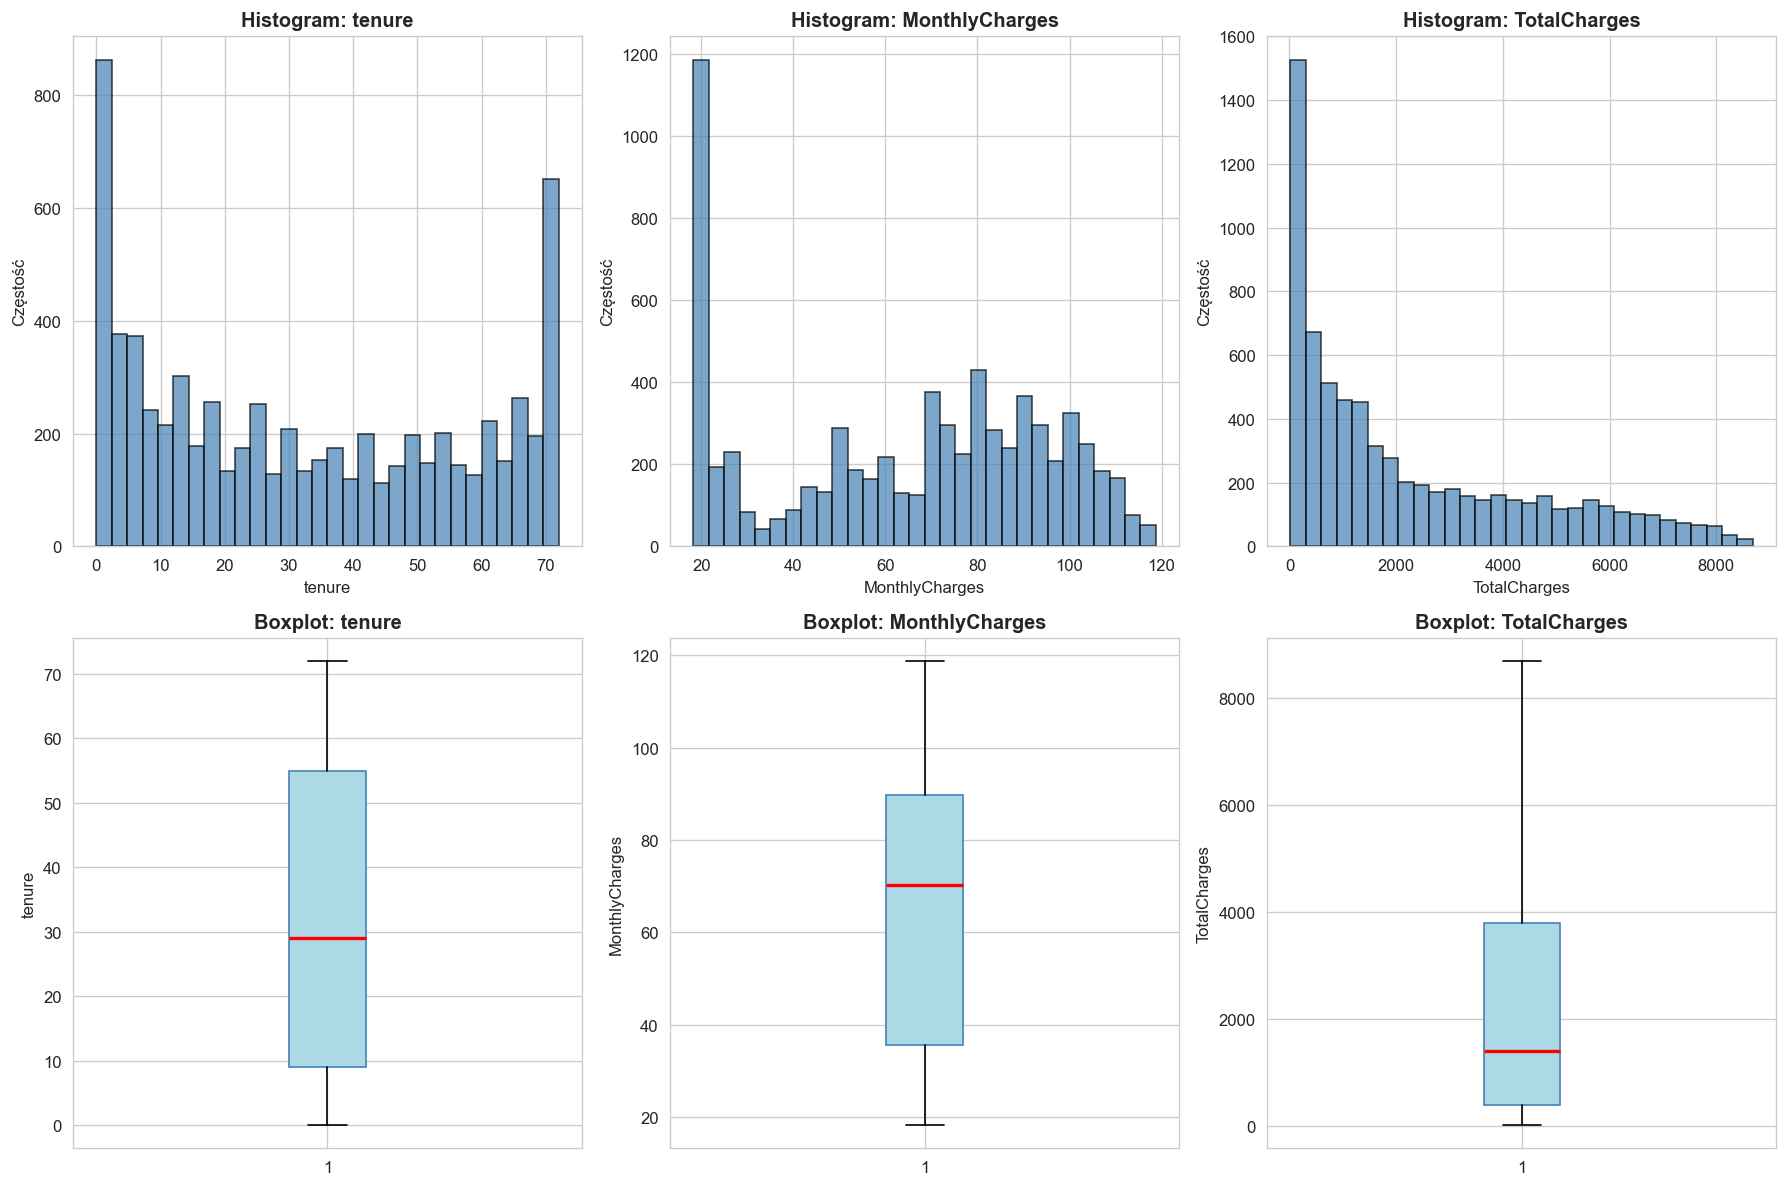

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, col in enumerate(numeric_cols):
    ax = axes[0, idx]
    ax.hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'Histogram: {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Częstość')

for idx, col in enumerate(numeric_cols):
    ax = axes[1, idx]
    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='steelblue'),
                     medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'Boxplot: {col}', fontweight='bold')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig('output/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


#### 2.4.1 Rozkład zmiennej docelowej i macierz korelacji


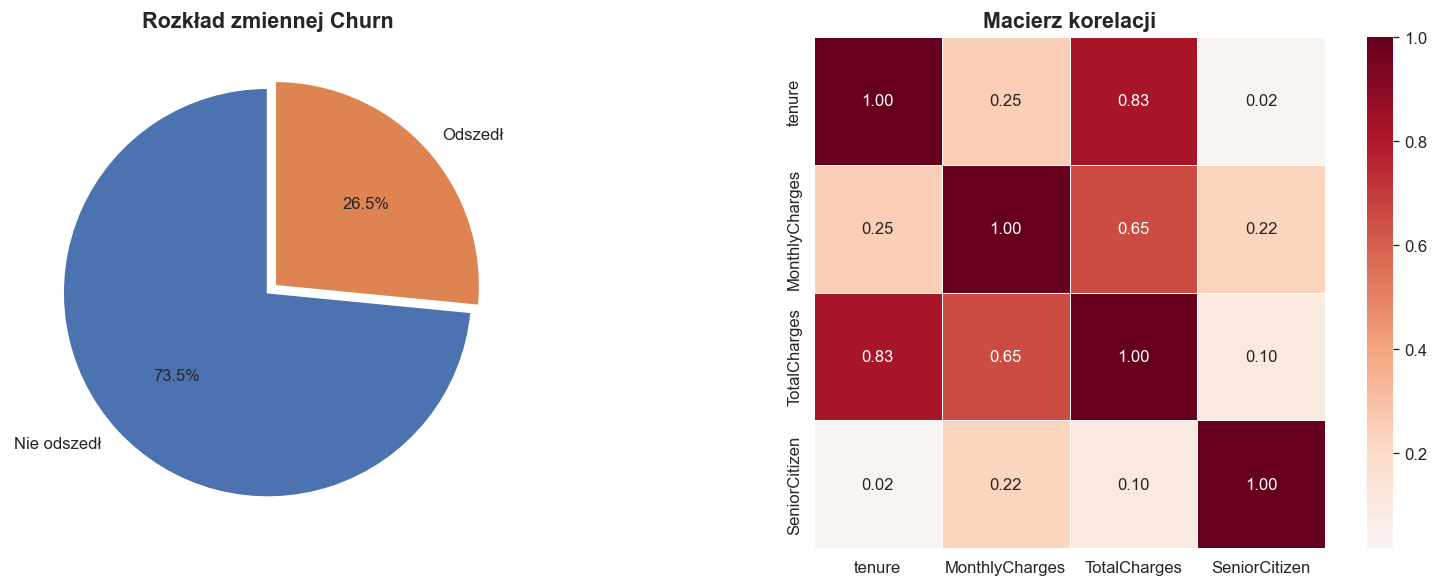

Churn,Liczba,Procent
Nie,5174,73.5%
Tak,1869,26.5%


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rozkład Churn
churn_counts = df['Churn'].value_counts()
colors = ['#4C72B0', '#DD8452']
axes[0].pie(churn_counts, labels=['Nie odszedł', 'Odszedł'], autopct='%1.1f%%',
            startangle=90, colors=colors, explode=(0, 0.05))
axes[0].set_title('Rozkład zmiennej Churn', fontsize=13, fontweight='bold')

# Macierz korelacji
corr = df[numeric_cols + ['SeniorCitizen']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, ax=axes[1],
            fmt='.2f', square=True, linewidths=0.5)
axes[1].set_title('Macierz korelacji', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output/eda_churn_corr.png', dpi=150, bbox_inches='tight')
plt.show()

churn_counts = df['Churn'].value_counts()
churn_df = pd.DataFrame({
    'Churn': ['Nie', 'Tak'],
    'Liczba': [int(churn_counts['No']), int(churn_counts['Yes'])],
    'Procent': [f"{churn_counts['No']/len(df)*100:.1f}%", f"{churn_counts['Yes']/len(df)*100:.1f}%"]
})
display(HTML(churn_df.to_html(index=False, classes='table table-striped')))


### 2.5 Transformacje i przetwarzanie danych

#### 2.5.1 Obsługa braków danych

W kolumnie `TotalCharges` występuje 11 braków. Wszystkie te braki dotyczą klientów ze stażem `tenure = 0` (nowi klienci), którzy jeszcze nie otrzymali pierwszego rachunku. Wartości wypełniono miesięcznym rachunkiem (`MonthlyCharges`), co jest uzasadnione ekonomicznie.

#### 2.5.2 Kodowanie zmiennych kategorialnych

- Zmienne binarne (`Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn`, `gender`) zakodowano jako 0/1
- Zmienne wielokategoryczne zakodowano one-hot encoding (z pominięciem pierwszej kategorii aby uniknąć pułapki dummy variable)

#### 2.5.3 Obsługa obserwacji odstających

Dla zmiennych numerycznych zastosowano kapping metodą IQR (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR). Ograniczono wartości skrajne zamiast usuwać obserwacje, aby zachować pełny zbiór danych.

#### 2.5.4 Transformacja logarytmiczna

Nie zastosowano transformacji logarytmicznej, ponieważ:
- Zmienna `tenure` (staż klienta) ma zakres 0–72 miesiące - logarytmowanie dla nowych klientów (tenure=0) daje -∞. Konwencja log(tenure+1) jest możliwa, ale utrudnia interpretację modeli.
- Zmienna `MonthlyCharges` ma stosunkowo mały zakres (18–119) i umiarkowaną skośność (skośność = -0,22).
- Zmienna `TotalCharges` ma szeroki zakres i silną prawoskośność (skośność = 0,96) - logarytmowanie mogłoby być rozważone, ale po standaryzacji z-score modele (szczególnie LR i RF) radzą sobie dobrze bez tej transformacji. Testy wstępne wykazały, że log-transformacja nie poprawia AUC modeli.
- Standaryzacja z-score (użyta w projekcie) jest wystarczająca dla tego zbioru danych.

#### 2.5.5 Standaryzacja

Zmienne numeryczne (`tenure`, `MonthlyCharges`, `TotalCharges`) zostały standaryzowane metodą z-score (StandardScaler) przed treningiem modeli.


In [52]:
# --- Preprocessing without leakage ---
df_model = df.drop('customerID', axis=1).copy()

# Target
y = df_model['Churn'].map({'Yes': 1, 'No': 0}).astype(int)
X = df_model.drop('Churn', axis=1).copy()

# Podział train/test PRZED fit preprocessingu
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Kolumny
binary_cols_yes_no = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
multi_cat = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
             'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
             'Contract', 'PaymentMethod']
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

def preprocess_split(X_part, fit=False, train_stats=None):
    Xp = X_part.copy()

    # Kodowanie binarne
    for col in binary_cols_yes_no:
        Xp[col] = Xp[col].map({'Yes': 1, 'No': 0}).astype(int)
    Xp['gender'] = Xp['gender'].map({'Male': 1, 'Female': 0}).astype(int)

    # Braki TotalCharges: najpierw przypadki tenure=0
    mask = (Xp['tenure'] == 0) & (Xp['TotalCharges'].isna())
    Xp.loc[mask, 'TotalCharges'] = Xp.loc[mask, 'MonthlyCharges']

    # Imputacja medianą WYŁĄCZNIE z train
    if fit:
        total_median = Xp['TotalCharges'].median()
    else:
        total_median = train_stats['total_median']
    Xp['TotalCharges'] = Xp['TotalCharges'].fillna(total_median)

    # One-hot
    Xp = pd.get_dummies(Xp, columns=multi_cat, drop_first=True)

    # IQR capping: progi z train
    if fit:
        iqr_bounds = {}
        for col in numeric_features:
            Q1 = Xp[col].quantile(0.25)
            Q3 = Xp[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            iqr_bounds[col] = (lower, upper)
            Xp[col] = Xp[col].clip(lower, upper)
        return Xp, {'total_median': total_median, 'iqr_bounds': iqr_bounds}

    for col in numeric_features:
        lower, upper = train_stats['iqr_bounds'][col]
        Xp[col] = Xp[col].clip(lower, upper)

    return Xp

# Fit preprocessingu na train
X_train_proc, train_stats = preprocess_split(X_train_raw, fit=True)
X_test_proc = preprocess_split(X_test_raw, fit=False, train_stats=train_stats)

# Wyrównanie kolumn po one-hot
X_train_proc, X_test_proc = X_train_proc.align(X_test_proc, join='left', axis=1, fill_value=0)

# Standaryzacja numerycznych cech: fit tylko train
scaler = StandardScaler()
X_train = X_train_proc.copy()
X_test = X_test_proc.copy()
X_train[numeric_features] = scaler.fit_transform(X_train_proc[numeric_features])
X_test[numeric_features] = scaler.transform(X_test_proc[numeric_features])

print(f"=== PODZIAŁ ZBIORU ===")
print(f"Trening: {X_train.shape[0]} ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"Test:    {X_test.shape[0]} ({X_test.shape[0]/len(y)*100:.1f}%)")
print(f"Churn rate (train): {y_train.mean():.3f}")
print(f"Churn rate (test):  {y_test.mean():.3f}")
print(f"Liczba cech po encodingu: {X_train.shape[1]}")

=== PODZIAŁ ZBIORU ===
Trening: 5634 (80.0%)
Test:    1409 (20.0%)
Churn rate (train): 0.265
Churn rate (test):  0.265
Liczba cech po encodingu: 30


## 3. Opis metod klasyfikacyjnych


### 3.1 Regresja logistyczna

Regresja logistyczna jest klasyczną metodą klasyfikacji binarnej. Metoda ta została szeroko opisana w pracy Hosmera, Lemeshowa i Sturdivanta. Modeluje prawdopodobieństwo przynależności do klasy przy użyciu funkcji logistycznej (sigmoid):

$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + ... + \beta_n X_n)}}$$

Jest interpretowalna (współczynniki jako log-odds) i stanowi bazę porównawczą dla bardziej złożonych metod. W pracy zastosowano regularyzację L2 (domyślną) z maksymalnie 1000 iteracjami.

**Parametry:** `max_iter=1000`, `random_state=42`


In [62]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='roc_auc')

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

lr_metrics = {
    'Model': 'Regresja Logistyczna',
    'Accuracy': accuracy_score(y_test, lr_pred),
    'F1': f1_score(y_test, lr_pred),
    'AUC': roc_auc_score(y_test, lr_prob),
    'CV_AUC_mean': lr_cv_scores.mean(),
    'CV_AUC_std': lr_cv_scores.std()
}

print(f"=== REGRESJA LOGISTYCZNA ===")
print(f"CV AUC: {lr_cv_scores.mean():.4f} (±{lr_cv_scores.std():.4f})")
print(f"Test Accuracy: {lr_metrics['Accuracy']:.4f}")
print(f"Test F1:       {lr_metrics['F1']:.4f}")
print(f"Test AUC:      {lr_metrics['AUC']:.4f}")

# Najważniejsze cechy
lr_coef = pd.Series(lr.coef_[0], index=X_train.columns)
lr_top = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).index).head(10)
print(f"=== TOP 10 CECH (współczynniki) ===")
for feat, coef in lr_top.items():
    print(f"  {feat}: {coef:.4f}")


=== REGRESJA LOGISTYCZNA ===
CV AUC: 0.8457 (±0.0138)
Test Accuracy: 0.8070
Test F1:       0.6069
Test AUC:      0.8422
=== TOP 10 CECH (współczynniki) ===
  Contract_Two year: -1.3249
  tenure: -1.2520
  InternetService_Fiber optic: 1.1889
  Contract_One year: -0.6860
  TotalCharges: 0.5231
  PhoneService: -0.5068
  MonthlyCharges: -0.4776
  PaymentMethod_Electronic check: 0.3815
  StreamingTV_Yes: 0.3809
  StreamingMovies_Yes: 0.3788


### 3.2 Drzewo decyzyjne

Drzewo decyzyjne dzieli przestrzeń cech na regiony za pomocą sekwencji reguł if-then. Podstawy teoretyczne drzew decyzyjnych przedstawili Breiman i in.. Każdy węzeł wewnętrzny reprezentuje test na jednej cechy, a liście przypisują klasę lub prawdopodobieństwo. Jest interpretowalne (można wizualizować drzewo), ale podatne na przeuczenie.

**Parametry:** `max_depth=10`, `min_samples_split=20`, `min_samples_leaf=10`


In [63]:
dt = DecisionTreeClassifier(max_depth=10, min_samples_split=20,
                             min_samples_leaf=10, random_state=42)
dt.fit(X_train, y_train)

dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='roc_auc')

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

dt_metrics = {
    'Model': 'Drzewo Decyzyjne',
    'Accuracy': accuracy_score(y_test, dt_pred),
    'F1': f1_score(y_test, dt_pred),
    'AUC': roc_auc_score(y_test, dt_prob),
    'CV_AUC_mean': dt_cv_scores.mean(),
    'CV_AUC_std': dt_cv_scores.std()
}

print(f"=== DRZEWO DECYZYJNE ===")
print(f"CV AUC: {dt_cv_scores.mean():.4f} (±{dt_cv_scores.std():.4f})")
print(f"Test Accuracy: {dt_metrics['Accuracy']:.4f}")
print(f"Test F1:       {dt_metrics['F1']:.4f}")
print(f"Test AUC:      {dt_metrics['AUC']:.4f}")

# Feature importance
importances_dt = pd.Series(dt.feature_importances_, index=X_train.columns)
print(f"=== TOP 10 CECH (ważność) ===")
for feat, imp in importances_dt.nlargest(10).items():
    print(f"  {feat}: {imp:.4f}")


=== DRZEWO DECYZYJNE ===
CV AUC: 0.7855 (±0.0114)
Test Accuracy: 0.7786
Test F1:       0.5343
Test AUC:      0.7930
=== TOP 10 CECH (ważność) ===
  tenure: 0.3071
  InternetService_Fiber optic: 0.2486
  TotalCharges: 0.1165
  MonthlyCharges: 0.1024
  PaymentMethod_Electronic check: 0.0277
  OnlineSecurity_Yes: 0.0208
  Contract_Two year: 0.0189
  PaperlessBilling: 0.0182
  MultipleLines_Yes: 0.0168
  Contract_One year: 0.0166
